In [71]:
import sklearn as sk
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from ydata_profiling import ProfileReport
import pymysql
import seaborn as sns
import scipy.stats as stat
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression,RidgeClassifier
from sklearn.metrics import f1_score,recall_score,precision_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomTreesEmbedding



In [2]:

# Get data from mysql Databases
conn=pymysql.connect(
    host='localhost',
    user='app',
    password='12345',
    database= 'churn_'
)

cursor_=conn.cursor()
query =' select * from Account_ a  join Churn_status cs  join Customer_ C ON a.CustomerId=cs.CustomerId and  a.CustomerId =C.CustomerId ;'
cursor_.execute (query)
data =cursor_.fetchall()
columns = [col[0] for col in cursor_.description]
df = pd.DataFrame(data, columns=columns)
cursor_.close
conn.close

<bound method Connection.close of <pymysql.connections.Connection object at 0x793c520dfe00>>

Data set diambil dari databases dalam mysql. 
Data frame berisi data customer churn

# Clening data frame 

In [3]:
df.head()

,CustomerId,CreditScore,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,code,CustomerId,Exited,code,CustomerId,Surname,Geography,Gender,Age
0,15565701,698,9,161994.0,1,0,0,90212.4,1,15565701,0,1,15565701,Ferri,Spain,Female,39
1,15565706,612,1,0.0,1,1,1,83256.3,2,15565706,1,2,15565706,Akobundu,Spain,Male,35
2,15565714,601,1,64430.1,2,0,1,96518.0,3,15565714,0,3,15565714,Cattaneo,France,Male,47
3,15565779,627,6,57809.3,1,1,0,188258.0,4,15565779,0,4,15565779,Kent,Germany,Female,30
4,15565796,745,10,96048.5,1,1,0,74510.6,5,15565796,0,5,15565796,Docherty,Germany,Male,48


In [4]:
# menghilangkan duplivcate columns
df.head()
df=df.loc[:, ~df.columns.duplicated(keep='last')]
col=df.columns
print (col)
df.columns=df.columns.str.lower()

Index(['CreditScore', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited', 'code', 'CustomerId',
       'Surname', 'Geography', 'Gender', 'Age'],
      dtype='object')


In [5]:
df=df.drop(['customerid','surname'], axis =1)

In [6]:
# cek data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   creditscore      10000 non-null  int64  
 1   tenure           10000 non-null  int64  
 2   balance          10000 non-null  float64
 3   numofproducts    10000 non-null  int64  
 4   hascrcard        10000 non-null  int64  
 5   isactivemember   10000 non-null  int64  
 6   estimatedsalary  10000 non-null  float64
 7   exited           10000 non-null  int64  
 8   code             10000 non-null  int64  
 9   geography        10000 non-null  object 
 10  gender           10000 non-null  object 
 11  age              10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [7]:
df=df.drop(['code'],axis=1)

In [8]:
df.isnull().sum()

creditscore        0
tenure             0
balance            0
numofproducts      0
hascrcard          0
isactivemember     0
estimatedsalary    0
exited             0
geography          0
gender             0
age                0
dtype: int64

In [9]:
df.shape

(10000, 11)

In [10]:
# save data frame 
df.to_csv('dataset.csv')

Dilakuakan pembersihan data, mendelete column yang tidak penting\n
1. Id (Nilai unik yang berbeda setiap nilainya dan tidak memiliki pola)
2. code (column tamabahan pada tabel di Databases)

# EDA 

In [11]:
# analisis
df.describe()

,creditscore,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,exited,age
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000
mean,650.528800,5.012800,76485.893499,1.530200,0.70550,0.515100,100090.238310,0.203700,38.921800
std,96.653299,2.892174,62397.409257,0.581654,0.45584,0.499797,57510.491457,0.402769,10.487806
min,350.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,18.000000
25%,584.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.125000,0.000000,32.000000
50%,652.000000,5.000000,97198.550000,1.000000,1.00000,1.000000,100193.500000,0.000000,37.000000
75%,718.000000,7.000000,127644.000000,2.000000,1.00000,1.000000,149388.000000,0.000000,44.000000
max,850.000000,10.000000,250898.000000,4.000000,1.00000,1.000000,199992.000000,1.000000,92.000000


In [12]:
profile=ProfileReport (df,title='profiling Report')

profile.to_file("report_timeseries.html")
profile.to_notebook_iframe()


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 11/11 [00:01<00:00,  9.73it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Ket : 
1. data tidak memiliki missing value 
2. Penyeberan data bersifat mendekati Normal pada column numerik, kecuali data column estimatedSalary dan tenure.
Sehingga dilihat dari corelasi dengan target exited tidak terlalu kuat.
3. corelation data kategorical yang memiliki sedikit pengaruh pada nilai target exited  adalah HasCrCard
4. estimatedSalry, tenure, dan has card tidak memilik corelasi dengan column lain.


# Feature Engenering 


1. split data train dan test

In [13]:
columns_=df.columns
type (columns_)
columns_

Index(['creditscore', 'tenure', 'balance', 'numofproducts', 'hascrcard',
       'isactivemember', 'estimatedsalary', 'exited', 'geography', 'gender',
       'age'],
      dtype='object')

In [78]:
var_x = [x for x in columns_ if x != 'exited']
var_target=['exited']
x= df[var_x]
y=df[var_target]

x_train, x_test ,y_train, y_test = train_test_split(x,y ,test_size=0.25,random_state=42 )

In [79]:
print ('nilai train feature')
print (x_train .head())
print ('target train feature')
print (y_train .head())
print ('nilai test feature')
print (x_test .head())
print ('target test feature')
print (y_test  .head())


nilai train feature
      creditscore  tenure   balance  numofproducts  hascrcard  isactivemember  \
4901          673       0       0.0              1          1               1   
4375          703       1  149762.0              1          1               0   
6698          737       4  127553.0              2          1               0   
9805          630       8       0.0              2          0               1   
1101          639      10  128174.0              2          1               0   

      estimatedsalary geography gender  age  
4901         85733.30    France   Male   65  
4375         20629.40    France   Male   37  
6698          4225.11   Germany   Male   50  
9805         79377.50    France   Male   50  
1101         59093.40   Germany   Male   35  
target train feature
      exited
4901       0
4375       1
6698       0
9805       0
1101       0
nilai test feature
      creditscore  tenure   balance  numofproducts  hascrcard  isactivemember  \
6252          694 

2. Cek Outlier data numerik 

In [16]:
# columns
columns_

Index(['creditscore', 'tenure', 'balance', 'numofproducts', 'hascrcard',
       'isactivemember', 'estimatedsalary', 'exited', 'geography', 'gender',
       'age'],
      dtype='object')

In [17]:
# train (creditscore, balance, age )
%matplotlib inline
def grafikOut(df, column):
    fig, ax =plt.subplots(1,3,figsize=(16,4))
    sns.histplot (data=df,x=column,ax =ax[0])
    sns.boxplot(data=df[column], ax =ax[1])
    stat.probplot(df[column], dist="norm", plot=plt)
    plt.show()
    



creditscore


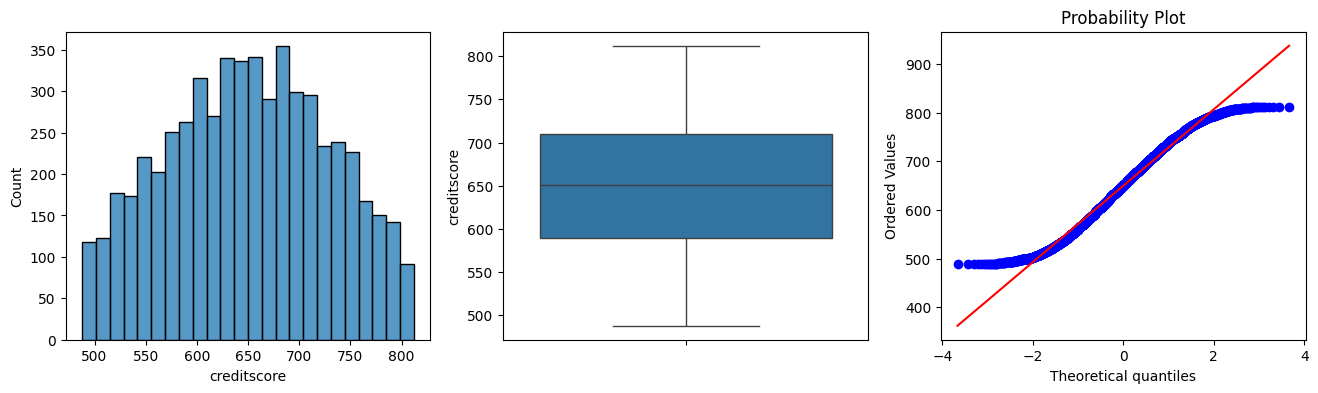

balance


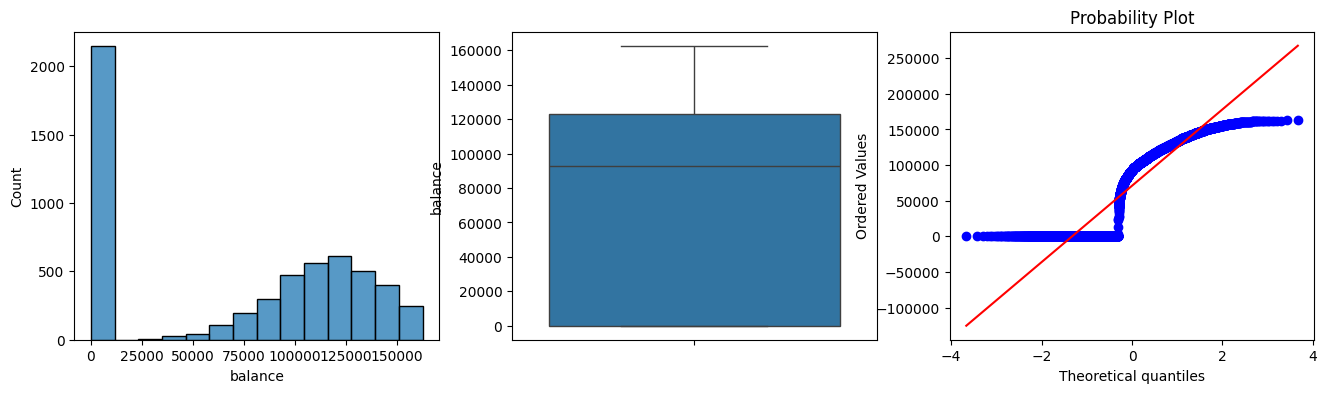

age


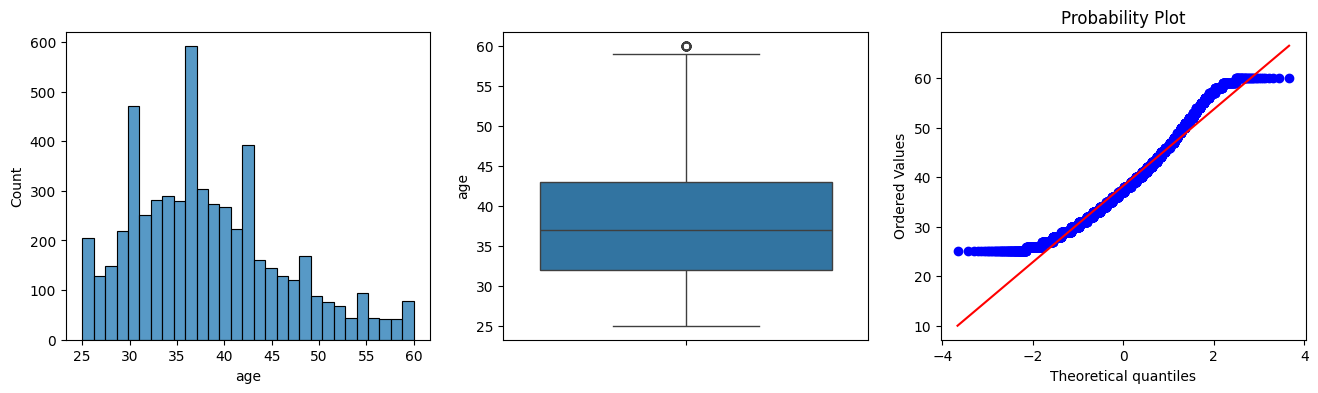

In [83]:
cols =['creditscore','balance','age']
for col in cols:
    print(col)
    grafikOut(x_train,col)

In [80]:
# atasi data outlier 
# creditscore 
analyst=x_train.describe()
x_train.describe()

,creditscore,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,age
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,649.655867,5.013467,76353.157132,1.530000,0.703333,0.517733,99468.561971,39.026267
std,96.945551,2.888829,62285.945041,0.581101,0.456819,0.499719,57468.339894,10.481207
min,350.000000,0.000000,0.000000,1.000000,0.000000,0.000000,91.750000,18.000000
25%,583.000000,3.000000,0.000000,1.000000,0.000000,0.000000,50566.100000,32.000000
50%,651.000000,5.000000,97339.100000,1.000000,1.000000,1.000000,98896.700000,37.000000
75%,717.000000,8.000000,127322.750000,2.000000,1.000000,1.000000,148580.500000,44.000000
max,850.000000,10.000000,250898.000000,4.000000,1.000000,1.000000,199992.000000,92.000000


In [81]:
def IQR_(df,column):
    Q1 =df[column ].quantile (0.25)
    Q3 =df[column].quantile (0.75)
    IQR =Q3 -Q1 
    return IQR,Q3,Q1

def batas(df,column):
    std_=df[column].std()
    iqr,q3,q1 =IQR_(df,column)
    up=q3+iqr*std_
    bot=q1-iqr*std_
    return up,bot

def mean_std(df,column):
    mean_=df[column].mean()
    std_=df[column].std()
    val =mean_+1.5*std_
    return val

def extrem_bat(df,column):
    atas =df[column].quantile(0.95)
    bawah =df[column].quantile(0.05)
    return atas, bawah


In [84]:
# extrim 
for col in cols :
    atas,bawah=extrem_bat(x_train,col)
    indx = x_train[x_train[col] >atas].index
    indx_=x_train[x_train[col]<bawah].index
    x_train=x_train.drop(indx)
    x_train=x_train.drop(indx_)
    y_train=y_train.drop(indx)
    y_train=y_train.drop(indx_)
    

creditscore


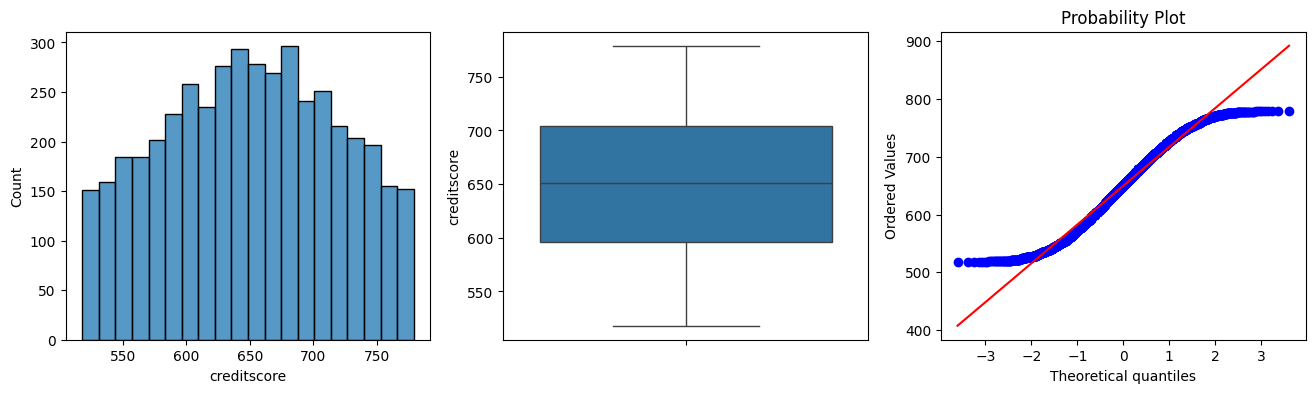

balance


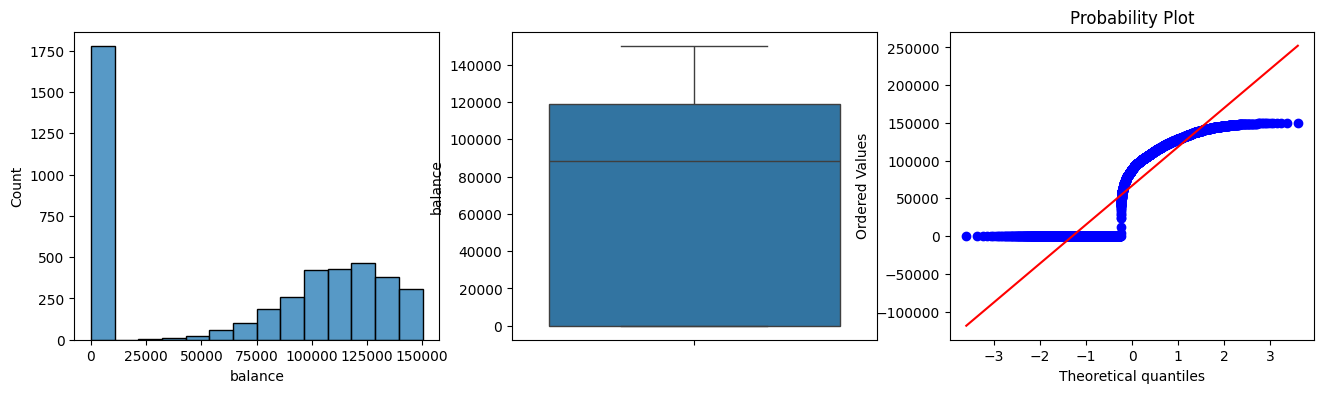

age


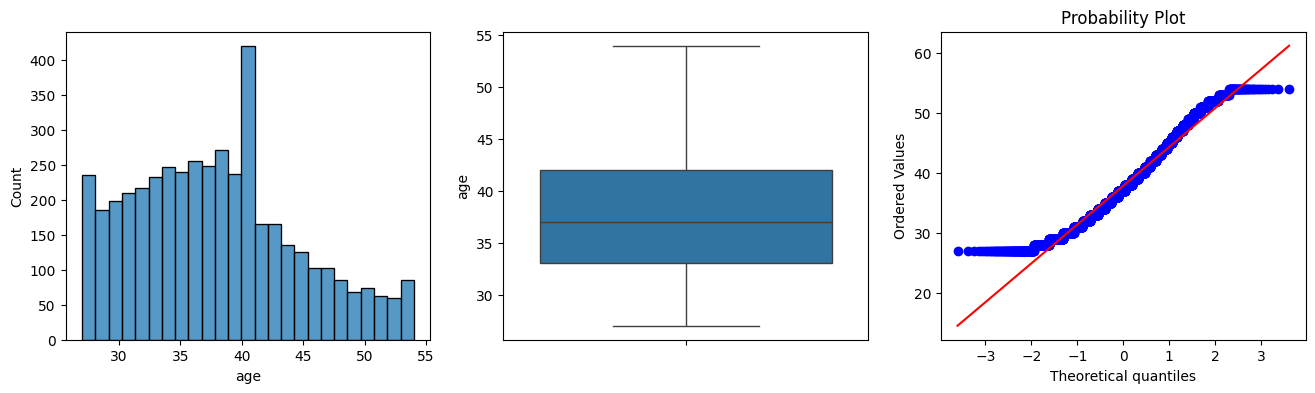

In [85]:
cols =['creditscore','balance','age']
for col in cols:
    print(col)
    grafikOut(x_train,col)

# standar scalling

In [75]:
x_train.info ()

<class 'pandas.core.frame.DataFrame'>
Index: 5811 entries, 4375 to 7270
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   creditscore      5811 non-null   float64
 1   tenure           5811 non-null   int64  
 2   balance          5811 non-null   float64
 3   numofproducts    5811 non-null   int64  
 4   hascrcard        5811 non-null   int64  
 5   isactivemember   5811 non-null   int64  
 6   estimatedsalary  5811 non-null   float64
 7   age              5811 non-null   float64
 8   France           5811 non-null   int64  
 9   Germany          5811 non-null   int64  
 10  Spain            5811 non-null   int64  
 11  Male             5811 non-null   int64  
 12  Female           5811 non-null   int64  
dtypes: float64(4), int64(9)
memory usage: 764.6 KB


In [76]:
x_train.columns

Index(['creditscore', 'tenure', 'balance', 'numofproducts', 'hascrcard',
       'isactivemember', 'estimatedsalary', 'age', 'France', 'Germany',
       'Spain', 'Male', 'Female'],
      dtype='object')

In [86]:
# max dan min
def max_min(df,column):
    max_ =df[column].max()
    min_=df[column].min()
    vals =[]
    for x in df[column]:
        val =(x-min_)/(max_-min_)
        vals.append (val)
    df [column]=vals
cols =['creditscore','balance','age','estimatedsalary']
for i in cols:
    max_min(x_train,i)

In [87]:
# x_test 

for i in cols:
    max_min(x_test,i)

In [88]:
x_train.head()

,creditscore,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,geography,gender,age
4375,0.708812,1,0.997177,1,1,0,0.102719,France,Male,0.370370
6698,0.839080,4,0.849300,2,1,0,0.020655,Germany,Male,0.851852
9805,0.429119,8,0.000000,2,0,1,0.396613,France,Male,0.851852
1101,0.463602,10,0.853435,2,1,0,0.295140,Germany,Male,0.296296
7655,0.865900,9,0.803790,1,1,1,0.294480,France,Male,0.148148


In [89]:
x_test.head()

,creditscore,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,geography,gender,age
6252,0.688,5,0.450109,1,0,0,0.561820,France,Female,0.148649
4684,0.666,7,0.000000,2,1,0,0.433263,France,Female,0.108108
1731,0.506,7,0.000000,1,1,0,0.990730,France,Male,0.189189
4742,0.666,5,0.733295,1,0,0,0.046075,Germany,Female,0.527027
4521,0.418,9,0.568398,1,1,0,0.879948,Spain,Male,0.662162


# ENCODING

In [90]:
columns=['geography','gender']

Karakter data tidak memiliki hirarki sehingga tingkatanya setara 
 

In [91]:
for col in columns:
    car =x_train[col].unique()
    for c in car:
        x_train[c]=np.where(
            x_train[col]==c,
            1,
            0
        )
        

In [92]:
x_train.head()

,creditscore,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,geography,gender,age,France,Germany,Spain,Male,Female
4375,0.708812,1,0.997177,1,1,0,0.102719,France,Male,0.370370,1,0,0,1,0
6698,0.839080,4,0.849300,2,1,0,0.020655,Germany,Male,0.851852,0,1,0,1,0
9805,0.429119,8,0.000000,2,0,1,0.396613,France,Male,0.851852,1,0,0,1,0
1101,0.463602,10,0.853435,2,1,0,0.295140,Germany,Male,0.296296,0,1,0,1,0
7655,0.865900,9,0.803790,1,1,1,0.294480,France,Male,0.148148,1,0,0,1,0


In [93]:
for col in columns:
    car =x_train[col].unique()
    for c in car:
        x_test[c]=np.where(
            x_test[col]==c,
            1,
            0
        )

In [94]:
x_test.head ()

,creditscore,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,geography,gender,age,France,Germany,Spain,Male,Female
6252,0.688,5,0.450109,1,0,0,0.561820,France,Female,0.148649,1,0,0,0,1
4684,0.666,7,0.000000,2,1,0,0.433263,France,Female,0.108108,1,0,0,0,1
1731,0.506,7,0.000000,1,1,0,0.990730,France,Male,0.189189,1,0,0,1,0
4742,0.666,5,0.733295,1,0,0,0.046075,Germany,Female,0.527027,0,1,0,0,1
4521,0.418,9,0.568398,1,1,0,0.879948,Spain,Male,0.662162,0,0,1,1,0


In [95]:
# drop column karakter sebelumnya
x_train =x_train.drop(columns=['gender','geography'])

In [96]:
x_test =x_test.drop(columns=['gender','geography'])

In [97]:
x_train.head()

,creditscore,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,age,France,Germany,Spain,Male,Female
4375,0.708812,1,0.997177,1,1,0,0.102719,0.370370,1,0,0,1,0
6698,0.839080,4,0.849300,2,1,0,0.020655,0.851852,0,1,0,1,0
9805,0.429119,8,0.000000,2,0,1,0.396613,0.851852,1,0,0,1,0
1101,0.463602,10,0.853435,2,1,0,0.295140,0.296296,0,1,0,1,0
7655,0.865900,9,0.803790,1,1,1,0.294480,0.148148,1,0,0,1,0


data sudah melalui proses fiture enginering

# Binding data

Data set yang disiapkan untuk digunakan pada model tree machine learning

In [37]:
x_tn=x_train[:]
x_ts=x_test[:]
y_tn =y_train[:]
y_ts =y_test[:]

In [38]:
x_tn.columns 

Index(['creditscore', 'tenure', 'balance', 'numofproducts', 'hascrcard',
       'isactivemember', 'estimatedsalary', 'age', 'France', 'Germany',
       'Spain', 'Male', 'Female'],
      dtype='object')

In [39]:
x_ts.columns 

Index(['creditscore', 'tenure', 'balance', 'numofproducts', 'hascrcard',
       'isactivemember', 'estimatedsalary', 'age', 'France', 'Germany',
       'Spain', 'Male', 'Female'],
      dtype='object')

In [40]:
def bins(x:int):
    ranges=(1/(x-1))
    batas=[]
    labels_=[]
    for i in range(x):
        j=i*ranges
        batas.append(j)
        label=i
        if i !=0:
            labels_.append (label)
    
    return batas,labels_

    

In [41]:
bins_,labels_=bins(5)

x_tn['creditscore_bins'] = pd.cut(x_tn['creditscore'], bins=bins_, labels=labels_)
x_ts['creditscore_bins'] = pd.cut(x_ts['creditscore'], bins=bins_, labels=labels_)

x_tn['balance_bins'] = pd.cut(x_tn['balance'], bins=bins_, labels=labels_)
x_ts['balance_bins'] = pd.cut(x_ts['balance'], bins=bins_, labels=labels_)

x_tn['age_bins'] = pd.cut(x_tn['age'], bins=bins_, labels=labels_)
x_ts['age_bins'] = pd.cut(x_ts['age'], bins=bins_, labels=labels_)


/tmp/ipykernel_28850/3592747778.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_tn['creditscore_bins'] = pd.cut(x_tn['creditscore'], bins=bins_, labels=labels_)
/tmp/ipykernel_28850/3592747778.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_ts['creditscore_bins'] = pd.cut(x_ts['creditscore'], bins=bins_, labels=labels_)
/tmp/ipykernel_28850/3592747778.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value 

In [42]:
x_tn.head()

,creditscore,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,age,France,Germany,Spain,Male,Female,creditscore_bins,balance_bins,age_bins
4375,0.663580,1,0.920468,1,1,0,0.102739,0.342857,1,0,0,1,0,3,4,2
6698,0.768519,4,0.783967,2,1,0,0.020677,0.714286,0,1,0,1,0,4,4,3
9805,0.438272,8,0.000000,2,0,1,0.396627,0.714286,1,0,0,1,0,2,NaN,3
1101,0.466049,10,0.787784,2,1,0,0.295155,0.285714,0,1,0,1,0,2,4,2
7655,0.790123,9,0.741958,1,1,1,0.294496,0.171429,1,0,0,1,0,4,3,1


In [43]:
x_tn.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5811 entries, 4375 to 7270
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   creditscore       5811 non-null   float64 
 1   tenure            5811 non-null   int64   
 2   balance           5811 non-null   float64 
 3   numofproducts     5811 non-null   int64   
 4   hascrcard         5811 non-null   int64   
 5   isactivemember    5811 non-null   int64   
 6   estimatedsalary   5811 non-null   float64 
 7   age               5811 non-null   float64 
 8   France            5811 non-null   int64   
 9   Germany           5811 non-null   int64   
 10  Spain             5811 non-null   int64   
 11  Male              5811 non-null   int64   
 12  Female            5811 non-null   int64   
 13  creditscore_bins  5806 non-null   category
 14  balance_bins      3596 non-null   category
 15  age_bins          5719 non-null   category
dtypes: category(3), float64(4)

In [44]:
idx=x_tn[x_tn["creditscore_bins"].isna()].index
x_tn.loc[idx,'creditscore']
x_tn=x_tn.fillna(1)
x_ts=x_ts.fillna(1)

# Build Model 

Data akan dilatih dengan model logistic regretion

In [99]:
model=LogisticRegression()
model.fit(x_train,y_train)
y_1 =model.predict  (x_test)
# analisis
f1_=f1_score(y_test,y_1)
recal=recall_score(y_test,y_1)
pres =precision_score (y_test,y_1)

print (f1_,recal,pres)


/home/syukrifjrn/my_dash_env/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


0.15157116451016636 0.08523908523908524 0.6833333333333333


In [46]:
# acak data
def acak(y_train):
    indx_t=y_train[y_train['exited']==1].index
    indx_f=y_train[y_train['exited']!=1].index
    indx_t = np.array(indx_t)
    indx_f=np.array(indx_f)


    np.random.shuffle(indx_f)
    total =int(len(indx_f)/len(indx_t))
    print (total)
 
    group_1,group_2, group_3=np.array_split(indx_f,3)

    return (
    np.concatenate([group_1, indx_t]),
    np.concatenate([group_2, indx_t]),
    np.concatenate([group_3, indx_t])
    )
    
group1,group2,group3= acak(y_train)
x_g1=x_train.loc[group1]
y_g1=y_train.loc[group1]

x_g2=x_train.loc[group2]
y_g2=y_train.loc[group2]

x_g3=x_train.loc[group3]
y_g3=y_train.loc[group3]

3


In [47]:
# test model dengan logsitic regretion
model_l1=LogisticRegression()
model_l1.fit (x_g1,y_g1)
y_1=model_l1.predict(x_test)
# analisis
f1_=f1_score(y_test,y_1)
recal=recall_score(y_test,y_1)
pres =precision_score (y_test,y_1)

print (f1_,recal,pres)


/home/syukrifjrn/my_dash_env/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


0.3850129198966408 0.3097713097713098 0.5085324232081911


In [48]:
# test model dengan logsitic regretion
model_l2=LogisticRegression()
model_l2.fit (x_g2,y_g2)
y_2 =model_l2.predict  (x_test)
# analisis
f1_=f1_score(y_test,y_2)
recal=recall_score(y_test,y_2)
pres =precision_score (y_test,y_2)

print (f1_,recal,pres)

/home/syukrifjrn/my_dash_env/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


0.39596469104665827 0.3264033264033264 0.5032051282051282


In [49]:
model_l3=LogisticRegression()
model_l3.fit (x_g3,y_g3)
y_3 =model_l3.predict  (x_test)
# analisis
f1_=f1_score(y_test,y_3)
recal=recall_score(y_test,y_3)
pres =precision_score (y_test,y_3)

print (f1_,recal,pres)

/home/syukrifjrn/my_dash_env/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


0.3979721166032953 0.3264033264033264 0.5097402597402597


In [50]:

# gabungkan jadi matrix
preds = np.vstack([y_1, y_2,y_3])

# voting mayoritas
y_pred = np.apply_along_axis(
    lambda x: np.bincount(x).argmax(), 
    axis=0, 
    arr=preds
)
f1_=f1_score(y_test,y_pred)
recal=recall_score(y_test,y_pred)
pres =precision_score (y_test,y_pred)

print (f1_,recal,pres)


0.39080459770114945 0.3180873180873181 0.5066225165562914


In [51]:
# delete column
x_train.columns 

Index(['creditscore', 'tenure', 'balance', 'numofproducts', 'hascrcard',
       'isactivemember', 'estimatedsalary', 'age', 'France', 'Germany',
       'Spain', 'Male', 'Female'],
      dtype='object')

dari coor

In [52]:
cols=['creditscore', 'balance', 'numofproducts', 
       'isactivemember', 'age', 'France', 'Germany',
       'Spain', 'Male', 'Female']

In [53]:
x_1=x_train[cols]
x_2=x_test[cols]
group1,group2,group3=acak(y_train)
x_g1=x_1.loc[group1]
y_g1=y_train.loc[group1]

x_g2=x_1.loc[group2]
y_g2=y_train.loc[group2]

x_g3=x_1.loc[group3]
y_g3=y_train.loc[group3]

3


In [54]:
model_l1=LogisticRegression()
model_l1.fit (x_g1,y_g1)
y_1=model_l1.predict(x_2)
# analisis
f1_=f1_score(y_test,y_1)
recal=recall_score(y_test,y_1)
pres =precision_score (y_test,y_1)

print (f1_,recal,pres)


/home/syukrifjrn/my_dash_env/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


0.3906856403622251 0.31392931392931395 0.5171232876712328


In [55]:
x_g1.columns

Index(['creditscore', 'balance', 'numofproducts', 'isactivemember', 'age',
       'France', 'Germany', 'Spain', 'Male', 'Female'],
      dtype='object')

In [56]:
x_test =x_test[cols]

In [57]:
model_r=RidgeClassifier()
model_r.fit(x_g1,y_g1)
y_1=model_r.predict(x_test)
# analisis
f1_=f1_score(y_test,y_1)
recal=recall_score(y_test,y_1)
pres =precision_score (y_test,y_1)

print (f1_,recal,pres)

0.3859191655801825 0.3076923076923077 0.5174825174825175


/home/syukrifjrn/my_dash_env/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:1332: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


tree

In [58]:
x_tn.columns
x_ts.columns

Index(['creditscore', 'tenure', 'balance', 'numofproducts', 'hascrcard',
       'isactivemember', 'estimatedsalary', 'age', 'France', 'Germany',
       'Spain', 'Male', 'Female', 'creditscore_bins', 'balance_bins',
       'age_bins'],
      dtype='object')

In [59]:
colls=[ 'tenure', 'numofproducts', 'hascrcard',
       'isactivemember', 'estimatedsalary', 'France', 'Germany',
       'Spain', 'Male', 'Female', 'creditscore_bins', 'balance_bins',
       'age_bins']

In [60]:
x_tn=x_tn [colls]
x_ts =x_ts[colls]

In [63]:
model_t1 =DecisionTreeClassifier(class_weight='balanced')
model_t1.fit(x_tn,y_tn)
y_pred= model_t1.predict (x_ts)
f1_=f1_score(y_ts,y_pred)
recal=recall_score(y_ts,y_pred)
pres =precision_score (y_ts,y_pred)

print (f1_,recal,pres)

0.361244019138756 0.31392931392931395 0.4253521126760563


In [64]:
group1,group2,group3= acak(y_tn)
x_g1=x_tn.loc[group1]
y_g1=y_tn.loc[group1]

x_g2=x_tn.loc[group2]
y_g2=y_tn.loc[group2]

x_g3=x_tn.loc[group3]
y_g3=y_tn.loc[group3]

3


In [66]:
# test model dengan logsitic regretion
model_l1=DecisionTreeClassifier()
model_l1.fit (x_g1,y_g1)
y_1=model_l1.predict(x_ts)
# analisis
f1_=f1_score(y_test,y_1)
recal=recall_score(y_test,y_1)
pres =precision_score (y_test,y_1)

print (f1_,recal,pres)


0.4129353233830846 0.5176715176715176 0.34344827586206894


In [68]:
# test model dengan logsitic regretion
model_l1=DecisionTreeClassifier()
model_l1.fit (x_g2,y_g2)
y_1=model_l1.predict(x_ts)
# analisis
f1_=f1_score(y_test,y_1)
recal=recall_score(y_test,y_1)
pres =precision_score (y_test,y_1)

print (f1_,recal,pres)


0.4282115869017632 0.5301455301455301 0.3591549295774648


In [69]:
# test model dengan logsitic regretion
model_l1=DecisionTreeClassifier()
model_l1.fit (x_g3,y_g3)
y_1=model_l1.predict(x_ts)
# analisis
f1_=f1_score(y_test,y_1)
recal=recall_score(y_test,y_1)
pres =precision_score (y_test,y_1)

print (f1_,recal,pres)

0.403580146460537 0.5155925155925156 0.3315508021390374


In [98]:
model_t2 = RandomTreesEmbedding()
model_t2.fit(x_train)

x_train_trans = model_t2.transform(x_train)
x_test_trans = model_t2.transform(x_test)



In [100]:
model=LogisticRegression(max_iter=1000)
model.fit(x_train_trans,y_train)
y_1 =model.predict  (x_test_trans)
# analisis
f1_=f1_score(y_test,y_1)
recal=recall_score(y_test,y_1)
pres =precision_score (y_test,y_1)

print (f1_,recal,pres)

/home/syukrifjrn/my_dash_env/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


0.20710059171597633 0.14553014553014554 0.358974358974359


In [103]:
model_t2 = RandomTreesEmbedding()
model_t2.fit(x_tn)

x_train_trans = model_t2.transform(x_tn)
x_test_trans = model_t2.transform(x_ts)
model_l1=DecisionTreeClassifier()
model_l1.fit (x_train_trans,y_tn)
y_1=model_l1.predict(x_test_trans)
# analisis
f1_=f1_score(y_test,y_1)
recal=recall_score(y_test,y_1)
pres =precision_score (y_test,y_1)

print (f1_,recal,pres)

0.3225806451612903 0.2806652806652807 0.3792134831460674


# kesimpulan

1. Featur data dirancang untuk dilatih pada model liniar logistik dan desicion tree
2. Model yang dihasilkan masih belum baik
3. Hasil fituring data tidak terlalu berpenagruh dari hasil pelatihan model.
4. hasil model yang konstan didapat dari model logistic regretion
f1 =0.3906856403622251 
recall =0.31392931392931395 
presisi=0.5171232876712328
5. Hubungan antara fiture dan target sangat kecil
6. diharapkan mencoba model lain dan menambah data set atau fitur tambahan untuk mamaksimalkan data